# Neural Networks Final Project (83695) - Part A

**Submitted by:** Noam Major (ID 208941989), Ziv Assoulin (ID 325312999)

This notebook analyzes electrical signal recordings of Spiny and Aspiny neurons. The analysis is done based on the provided project requirements, using `neurodata.npy` (stimulus + two voltage traces, sampled at 50 kHz).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
from scipy.stats import norm
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score
import seaborn as sns

# Plot styling
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style="whitegrid")

In [2]:
# ---------------------------------------------------------
# Data Loading Section
# ---------------------------------------------------------
file_path = "neurodata.npy"
fs = 50000  # 50 KHz sampling rate

print(f"Loading real data from {file_path}...")
data = np.load(file_path)

# neurodata.npy is a 2D array of shape (3, 401000): row 0 = injected stimulus current (pA),
# rows 1-2 = the two neurons' membrane voltage responses (mV).
stimulus = data[0]
time_vector = np.arange(len(stimulus)) / fs

# The PDF states the aspiny neuron is the one with the higher firing rate. We determine this
# directly from the data by counting suprathreshold peaks in each candidate row (a coarse
# threshold is enough here; the precise spike-detection threshold is chosen in Question 4).
coarse_threshold_mv = -20
raw_peak_counts = [
    len(signal.find_peaks(data[row], height=coarse_threshold_mv, distance=100)[0])
    for row in (1, 2)
]
print(f"Peak counts -> row 1: {raw_peak_counts[0]}, row 2: {raw_peak_counts[1]}")

aspiny_row = 1 if raw_peak_counts[0] > raw_peak_counts[1] else 2
spiny_row = 2 if aspiny_row == 1 else 1
aspiny_response = data[aspiny_row]
spiny_response = data[spiny_row]
print(f"-> Row {aspiny_row} has the higher firing rate => assigned as the ASPINY neuron.")
print(f"-> Row {spiny_row} has the lower firing rate => assigned as the SPINY neuron.")

# Locate the stimulus step edges directly from the data (rising/falling edges of the current),
# instead of hardcoding them, so later sections (Q7) can reuse the exact same window.
edges = np.flatnonzero(np.diff(stimulus) != 0) + 1
pulse1_start, pulse1_end = edges[0] / fs, edges[1] / fs   # short calibration pulse
pulse2_start, pulse2_end = edges[2] / fs, edges[3] / fs   # main current step used to drive spiking
print(f"Calibration pulse: {pulse1_start:.3f}-{pulse1_end:.3f} s (amplitude {stimulus[edges[0]]:.0f} pA)")
print(f"Main stimulus step: {pulse2_start:.3f}-{pulse2_end:.3f} s (amplitude {stimulus[edges[2]]:.0f} pA)")
print("Data is ready.")

Loading real data from neurodata.npy...
Peak counts -> row 1: 91, row 2: 25
-> Row 1 has the higher firing rate => assigned as the ASPINY neuron.
-> Row 2 has the lower firing rate => assigned as the SPINY neuron.
Calibration pulse: 0.005-0.015 s (amplitude 50 pA)
Main stimulus step: 1.020-2.020 s (amplitude 150 pA)
Data is ready.


### Question 1: Spiny and Aspiny Neurons

*   **Spiny Neurons:** These neurons have dendritic spines (small membranous protrusions) that receive synaptic input. They are typically excitatory neurons (such as pyramidal cells in the cerebral cortex) and use glutamate as their primary neurotransmitter. Spines help increase the surface area for synapses.
*   **Aspiny Neurons:** These neurons lack dendritic spines (smooth dendrites). In the cerebral cortex, they are most commonly inhibitory interneurons (e.g., basket cells) that release GABA. They often have higher baseline firing rates and play a crucial role in regulating and modulating the activity of excitatory circuits.

### Question 2: Electrical Stimulus over Time

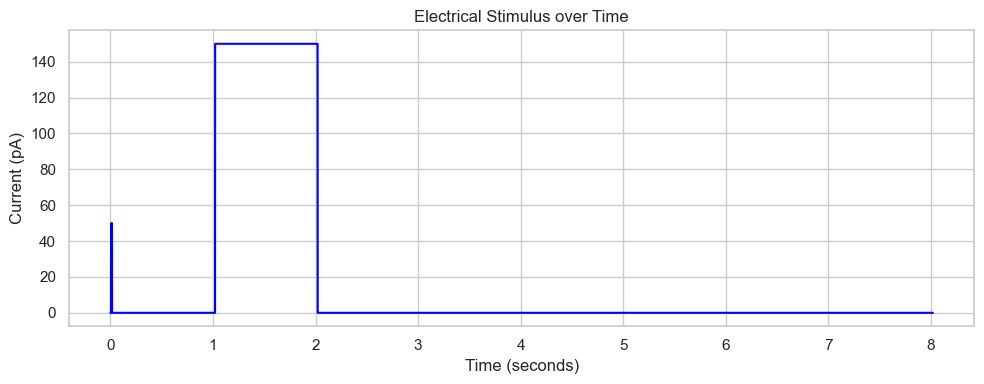

In [3]:
plt.figure(figsize=(10, 4))
plt.plot(time_vector, stimulus, color='blue')
plt.title('Electrical Stimulus over Time')
plt.xlabel('Time (seconds)')
plt.ylabel('Current (pA)')
plt.tight_layout()
plt.show()

**Stimulus Description:**
The stimulus is an injected electrical current (in pA) with two distinct pulses: a short **50 pA calibration/test pulse** (~10 ms, at 0.005-0.015 s) commonly used to estimate the cell's input resistance from its passive voltage response, followed after a quiet baseline period by the **main 150 pA current step, lasting 1 second (1.02-2.02 s)**. This main step depolarizes the membrane enough to drive repetitive spiking. After 2.02 s the current returns to 0 pA and stays there for the remainder of the ~8 s recording.

### Question 3: Electrical Activity of Spiny and Aspiny Neurons

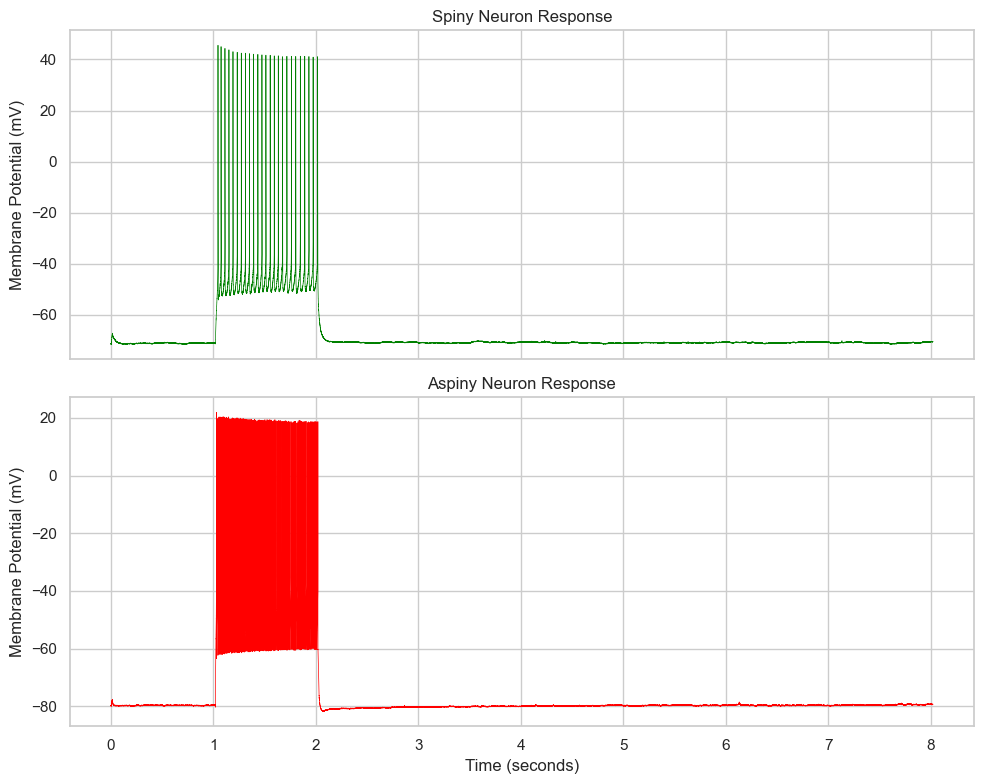

In [4]:
fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax[0].plot(time_vector, spiny_response, color='green', linewidth=0.5)
ax[0].set_title('Spiny Neuron Response')
ax[0].set_ylabel('Membrane Potential (mV)')

ax[1].plot(time_vector, aspiny_response, color='red', linewidth=0.5)
ax[1].set_title('Aspiny Neuron Response')
ax[1].set_xlabel('Time (seconds)')
ax[1].set_ylabel('Membrane Potential (mV)')

plt.tight_layout()
plt.show()

**Response Description & Differences:**
Both neurons fire action potentials (spikes) in response to the electrical stimulus. 
The main difference is the **firing rate**. The aspiny neuron exhibits a noticeably higher frequency of action potentials compared to the spiny neuron. The spiny neuron responds with fewer, more spaced-out spikes, while the aspiny neuron fires rapidly, which is characteristic of many fast-spiking inhibitory interneurons.

### Question 4: Spike Trains and Action Potential Threshold

Spiny  -> resting baseline ~-71.3 mV, spike peaks up to 45.6 mV
Aspiny -> resting baseline ~-80.7 mV, spike peaks up to 21.9 mV
Detected spikes at threshold=-20 mV -> spiny: 25, aspiny: 91


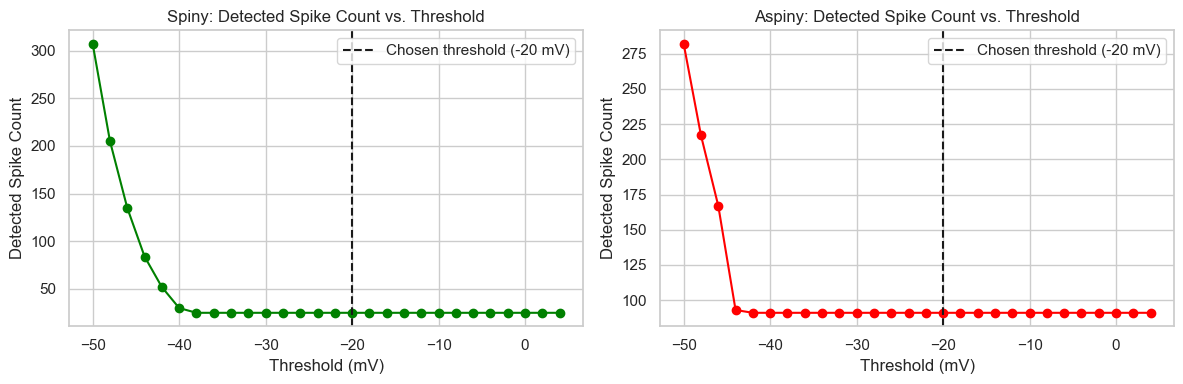

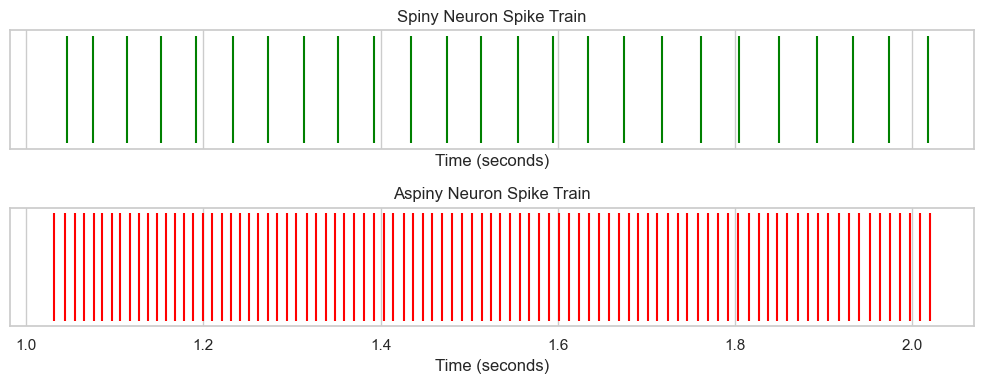

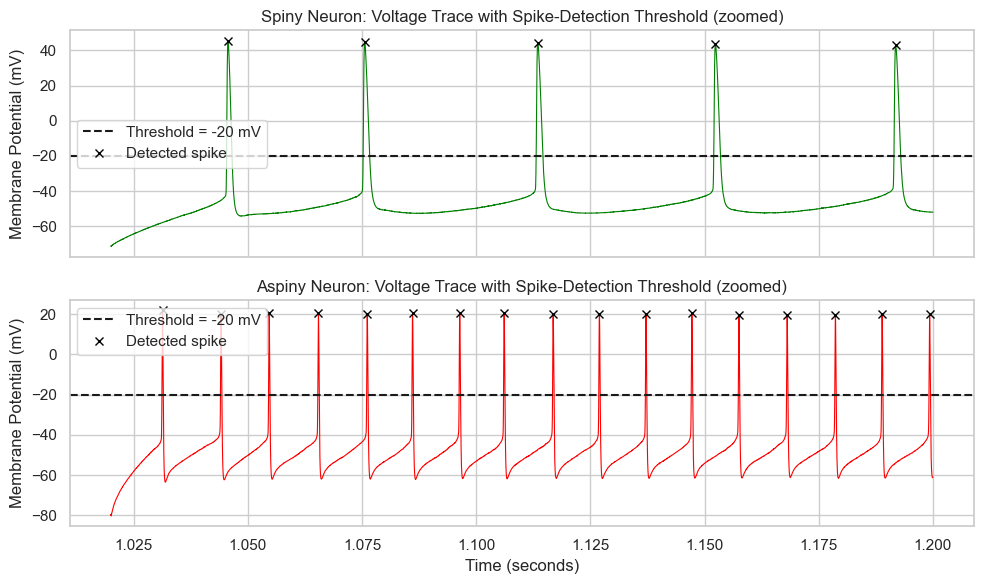

In [5]:
# Function to extract spike times
def extract_spikes(voltage_trace, threshold_mv, min_distance_samples=100):
    peaks, _ = signal.find_peaks(voltage_trace, height=threshold_mv, distance=min_distance_samples)
    return peaks

# Justify the threshold from the data: baseline resting potential vs. spike peak amplitude.
print(f"Spiny  -> resting baseline ~{np.percentile(spiny_response, 5):.1f} mV, spike peaks up to {spiny_response.max():.1f} mV")
print(f"Aspiny -> resting baseline ~{np.percentile(aspiny_response, 5):.1f} mV, spike peaks up to {aspiny_response.max():.1f} mV")

# We select a threshold of -20 mV: it sits in the empty gap between the resting/subthreshold
# range (well below -40 mV for both neurons) and the depolarized spike peaks (well above 0 mV).
threshold = -20

spiny_peaks = extract_spikes(spiny_response, threshold)
aspiny_peaks = extract_spikes(aspiny_response, threshold)
print(f"Detected spikes at threshold={threshold} mV -> spiny: {len(spiny_peaks)}, aspiny: {len(aspiny_peaks)}")

# Threshold sensitivity sweep: show that the spike count is stable across a wide range of
# thresholds, confirming -20 mV is a safe, non-arbitrary choice (not sitting on an edge case).
sweep_thresholds = np.arange(-50, 5, 2)
spiny_counts = [len(extract_spikes(spiny_response, t)) for t in sweep_thresholds]
aspiny_counts = [len(extract_spikes(aspiny_response, t)) for t in sweep_thresholds]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(sweep_thresholds, spiny_counts, 'o-', color='green')
ax[0].axvline(threshold, color='k', linestyle='--', label=f'Chosen threshold ({threshold} mV)')
ax[0].set_title('Spiny: Detected Spike Count vs. Threshold')
ax[0].set_xlabel('Threshold (mV)')
ax[0].set_ylabel('Detected Spike Count')
ax[0].legend()

ax[1].plot(sweep_thresholds, aspiny_counts, 'o-', color='red')
ax[1].axvline(threshold, color='k', linestyle='--', label=f'Chosen threshold ({threshold} mV)')
ax[1].set_title('Aspiny: Detected Spike Count vs. Threshold')
ax[1].set_xlabel('Threshold (mV)')
ax[1].set_ylabel('Detected Spike Count')
ax[1].legend()
plt.tight_layout()
plt.show()

# Create raster plots for spike trains
fig, ax = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
ax[0].vlines(time_vector[spiny_peaks], ymin=0, ymax=1, color='green')
ax[0].set_title('Spiny Neuron Spike Train')
ax[0].set_xlabel('Time (seconds)')
ax[0].set_yticks([])

ax[1].vlines(time_vector[aspiny_peaks], ymin=0, ymax=1, color='red')
ax[1].set_title('Aspiny Neuron Spike Train')
ax[1].set_xlabel('Time (seconds)')
ax[1].set_yticks([])

plt.tight_layout()
plt.show()

# Zoomed view of the voltage traces with the detection threshold and detected spikes marked,
# so the choice of threshold can be inspected visually.
zoom_idx = np.flatnonzero((time_vector >= 1.02) & (time_vector <= 1.2))
zoom_start, zoom_end = zoom_idx[0], zoom_idx[-1]
zoom = slice(zoom_start, zoom_end + 1)
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax[0].plot(time_vector[zoom], spiny_response[zoom], color='green', linewidth=0.8)
ax[0].axhline(threshold, color='k', linestyle='--', label=f'Threshold = {threshold} mV')
spiny_zoom_peaks = spiny_peaks[(spiny_peaks >= zoom_start) & (spiny_peaks <= zoom_end)]
ax[0].plot(time_vector[spiny_zoom_peaks], spiny_response[spiny_zoom_peaks], 'x', color='black', label='Detected spike')
ax[0].set_title('Spiny Neuron: Voltage Trace with Spike-Detection Threshold (zoomed)')
ax[0].set_ylabel('Membrane Potential (mV)')
ax[0].legend()

ax[1].plot(time_vector[zoom], aspiny_response[zoom], color='red', linewidth=0.8)
ax[1].axhline(threshold, color='k', linestyle='--', label=f'Threshold = {threshold} mV')
aspiny_zoom_peaks = aspiny_peaks[(aspiny_peaks >= zoom_start) & (aspiny_peaks <= zoom_end)]
ax[1].plot(time_vector[aspiny_zoom_peaks], aspiny_response[aspiny_zoom_peaks], 'x', color='black', label='Detected spike')
ax[1].set_title('Aspiny Neuron: Voltage Trace with Spike-Detection Threshold (zoomed)')
ax[1].set_xlabel('Time (seconds)')
ax[1].set_ylabel('Membrane Potential (mV)')
ax[1].legend()
plt.tight_layout()
plt.show()

**Threshold Selection:**
The threshold chosen for detecting action potentials is `-20 mV`. As shown above, both neurons rest around -70 to -80 mV and their spikes peak well above 0 mV, so -20 mV falls in a gap with essentially no data in it — the "Detected Spike Count vs. Threshold" sweep confirms this: the detected spike count is exactly constant (25 for spiny, 91 for aspiny) across roughly -35 to +2 mV, so the exact threshold value does not matter as long as it stays inside that plateau.

*   **If the threshold was too low (e.g., -50 mV):** It would sit inside the sub-threshold voltage fluctuations between spikes, so those fluctuations would be falsely detected as spikes, artificially inflating the firing rate and corrupting the ISI/CV statistics (in the sweep the detected count rises from 25 to about 300 for the spiny neuron, and from 91 to about 280 for the aspiny neuron, at -50 mV).
*   **If the threshold was too high (e.g., +40 mV):** It would exceed the actual peak voltage of some, or all, real action potentials (aspiny peaks only reach ~22 mV), causing genuine spikes to be missed and the firing rate to be artificially underestimated.

### Question 5: Inter-Spike Intervals (ISI) and Coefficient of Variation (CV)

Spikes during stimulus window -> spiny: 25/25, aspiny: 91/91 (all spikes fall inside the stimulus window)
Spiny Neuron CV: 0.070  (ISI range: 29.9-44.8 ms, n=24)
Aspiny Neuron CV: 0.049  (ISI range: 9.7-12.8 ms, n=90)


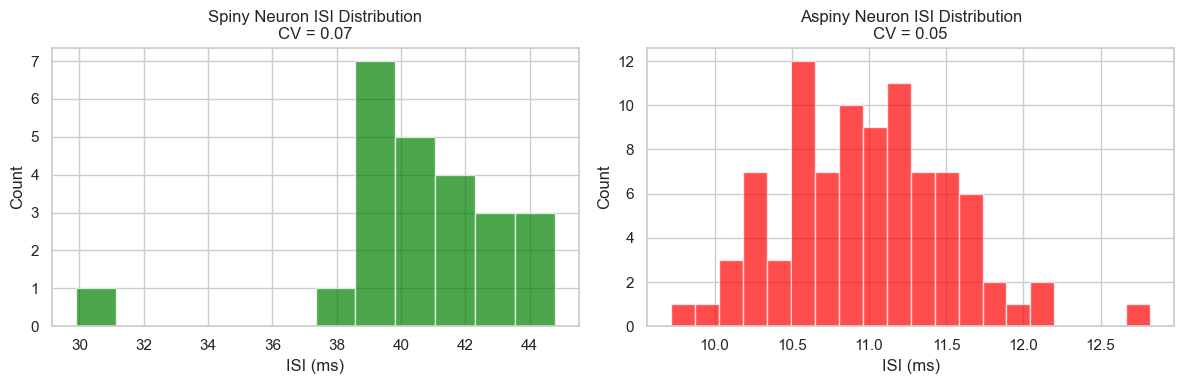

In [6]:
# The question asks for ISI/CV "during the electrical stimulus" -> restrict to spikes that
# occur within the main current step window (all detected spikes happen to fall inside it here,
# since neither neuron fires during the baseline or the short calibration pulse, but we filter
# explicitly rather than assume that).
spiny_peaks_stim = spiny_peaks[(spiny_peaks >= pulse2_start * fs) & (spiny_peaks <= pulse2_end * fs)]
aspiny_peaks_stim = aspiny_peaks[(aspiny_peaks >= pulse2_start * fs) & (aspiny_peaks <= pulse2_end * fs)]
print(f"Spikes during stimulus window -> spiny: {len(spiny_peaks_stim)}/{len(spiny_peaks)}, "
      f"aspiny: {len(aspiny_peaks_stim)}/{len(aspiny_peaks)} (all spikes fall inside the stimulus window)")

# Calculate ISI (Inter-Spike Intervals) in seconds
spiny_isi = np.diff(spiny_peaks_stim) / fs
aspiny_isi = np.diff(aspiny_peaks_stim) / fs

# Calculate CV (Coefficient of Variation) = std / mean
spiny_cv = np.std(spiny_isi) / np.mean(spiny_isi) if len(spiny_isi) > 0 else 0
aspiny_cv = np.std(aspiny_isi) / np.mean(aspiny_isi) if len(aspiny_isi) > 0 else 0

print(f"Spiny Neuron CV: {spiny_cv:.3f}  (ISI range: {spiny_isi.min()*1000:.1f}-{spiny_isi.max()*1000:.1f} ms, n={len(spiny_isi)})")
print(f"Aspiny Neuron CV: {aspiny_cv:.3f}  (ISI range: {aspiny_isi.min()*1000:.1f}-{aspiny_isi.max()*1000:.1f} ms, n={len(aspiny_isi)})")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(spiny_isi * 1000, bins=12, color='green', alpha=0.7)
ax[0].set_title(f'Spiny Neuron ISI Distribution\nCV = {spiny_cv:.2f}')
ax[0].set_xlabel('ISI (ms)')
ax[0].set_ylabel('Count')

ax[1].hist(aspiny_isi * 1000, bins=20, color='red', alpha=0.7)
ax[1].set_title(f'Aspiny Neuron ISI Distribution\nCV = {aspiny_cv:.2f}')
ax[1].set_xlabel('ISI (ms)')
ax[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

**Firing Pattern based on CV:**
*   $CV \ll 1$: Indicates a very regular, periodic firing pattern (Pacemaker-like).
*   $CV \approx 1$: Indicates a random, memoryless firing pattern (Poisson-like).
*   $CV > 1$: Indicates an irregular, clustered firing pattern (Bursty).

The measured CVs are **0.07 (spiny)** and **0.05 (aspiny)** — both far below 1, so **both neurons fire highly regularly during the stimulus, i.e. pacemaker-like**, not Poisson. The aspiny neuron is even more regular than the spiny neuron (lower CV), despite firing almost 4x faster. Looking at the ISI histograms, the intervals are tightly clustered (spiny: 29.9-44.8 ms; aspiny: 9.7-12.8 ms) rather than scattered randomly, and they tend to lengthen over the course of the step: the trend is upward but not strictly monotonic (the correlation between ISI and spike number is 0.68 for spiny and 0.59 for aspiny). This gradual ISI lengthening is **spike-frequency adaptation**, a common feature of sustained current-step responses, and it is the main source of the (still small) variability captured by the CV.

### Question 6: Time-Dependent Firing Rate

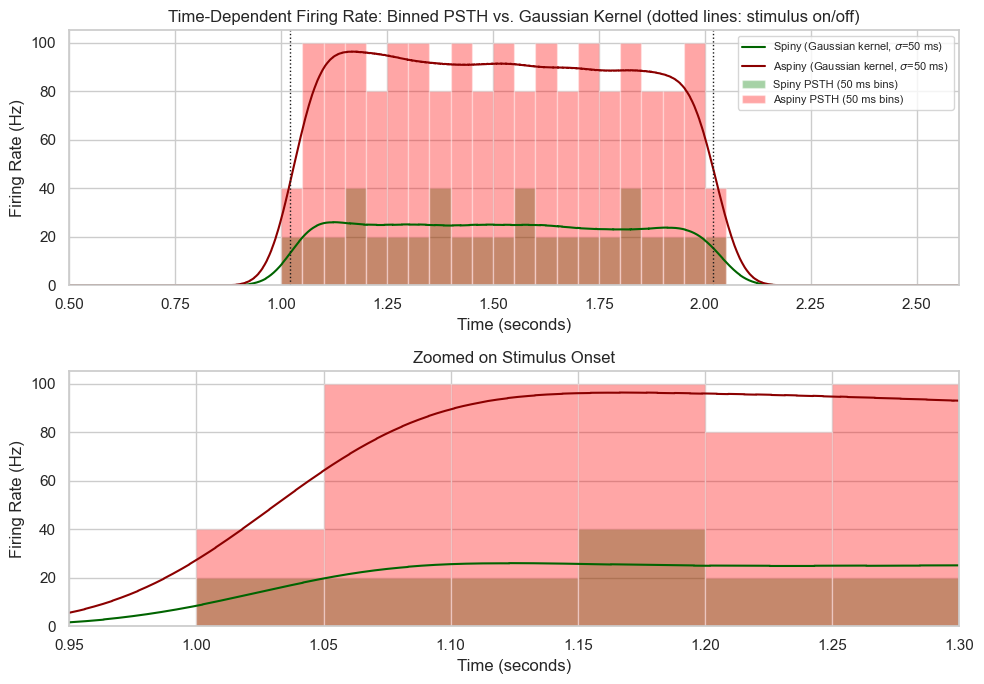

In [7]:
# We use a Gaussian kernel to estimate the continuous firing rate
def calculate_firing_rate(peaks, total_samples, fs, sigma_ms=50):
    spike_train = np.zeros(total_samples)
    spike_train[peaks] = 1
    
    # Create Gaussian window
    sigma_samples = int(sigma_ms * 1e-3 * fs)
    window_size = sigma_samples * 6
    window = signal.windows.gaussian(window_size, std=sigma_samples)
    window /= window.sum() # Normalize integral to 1
    
    # Convolve spike train with window and multiply by fs to get Hz
    firing_rate = signal.convolve(spike_train, window, mode='same') * fs
    return firing_rate

# We also compute a simple binned firing rate (PSTH): spike count per bin / bin width.
def binned_firing_rate(peaks, total_duration, fs, bin_ms=50):
    bin_width = bin_ms * 1e-3
    bin_edges = np.arange(0, total_duration + bin_width, bin_width)
    spike_times = peaks / fs
    counts, _ = np.histogram(spike_times, bins=bin_edges)
    rate = counts / bin_width
    bin_centers = bin_edges[:-1] + bin_width / 2
    return bin_centers, rate

sigma_ms = 50  # 50 ms Gaussian kernel
bin_ms = 50    # 50 ms bins for the PSTH, same resolution as the kernel for a fair comparison
spiny_rate_t = calculate_firing_rate(spiny_peaks, len(time_vector), fs, sigma_ms)
aspiny_rate_t = calculate_firing_rate(aspiny_peaks, len(time_vector), fs, sigma_ms)
spiny_bin_t, spiny_bin_rate = binned_firing_rate(spiny_peaks, time_vector[-1], fs, bin_ms)
aspiny_bin_t, aspiny_bin_rate = binned_firing_rate(aspiny_peaks, time_vector[-1], fs, bin_ms)

# Separate x-axes: the upper panel shows the whole response to the current step (onset and
# offset), the lower one zooms in on the onset. (With a shared axis, zooming one zooms both.)
fig, ax = plt.subplots(2, 1, figsize=(10, 7))
ax[0].bar(spiny_bin_t, spiny_bin_rate, width=bin_ms/1000, alpha=0.35, color='green', label=f'Spiny PSTH ({bin_ms} ms bins)')
ax[0].bar(aspiny_bin_t, aspiny_bin_rate, width=bin_ms/1000, alpha=0.35, color='red', label=f'Aspiny PSTH ({bin_ms} ms bins)')
ax[0].plot(time_vector, spiny_rate_t, color='darkgreen', label=f'Spiny (Gaussian kernel, $\\sigma$={sigma_ms} ms)')
ax[0].plot(time_vector, aspiny_rate_t, color='darkred', label=f'Aspiny (Gaussian kernel, $\\sigma$={sigma_ms} ms)')
for edge in (pulse2_start, pulse2_end):
    ax[0].axvline(edge, color='k', linestyle=':', linewidth=1)
ax[0].set_xlim(0.5, 2.6)
ax[0].set_title('Time-Dependent Firing Rate: Binned PSTH vs. Gaussian Kernel (dotted lines: stimulus on/off)')
ax[0].set_xlabel('Time (seconds)')
ax[0].set_ylabel('Firing Rate (Hz)')
ax[0].legend(fontsize=8)

# Zoomed view around the stimulus onset, where the two methods differ most visibly
zoom_on = (time_vector >= 0.95) & (time_vector <= 1.3)
ax[1].bar(spiny_bin_t, spiny_bin_rate, width=bin_ms/1000, alpha=0.35, color='green')
ax[1].bar(aspiny_bin_t, aspiny_bin_rate, width=bin_ms/1000, alpha=0.35, color='red')
ax[1].plot(time_vector[zoom_on], spiny_rate_t[zoom_on], color='darkgreen')
ax[1].plot(time_vector[zoom_on], aspiny_rate_t[zoom_on], color='darkred')
ax[1].set_xlim(0.95, 1.3)
ax[1].set_title('Zoomed on Stimulus Onset')
ax[1].set_xlabel('Time (seconds)')
ax[1].set_ylabel('Firing Rate (Hz)')

plt.tight_layout()
plt.show()

**Kernel / Window Choice:**
We show two estimators of the time-dependent firing rate:
*   **Binned PSTH** (50 ms bins): the simplest estimate — spike count per bin divided by the bin width. It is easy to compute and interpret, but is blocky/discontinuous and its value depends on the arbitrary alignment of bin edges relative to the spikes.
*   **Gaussian kernel** ($\sigma = 50$ ms): each spike contributes a smooth Gaussian "bump" of probability mass instead of a rectangular one, so the resulting rate function is continuous and not sensitive to bin placement. We chose $\sigma = 50$ ms because it is short enough to resolve the onset/offset of the 1 s current step (visible in the zoomed panel) while being long enough (relative to the ~10-45 ms ISIs) to average over several spikes and produce a smooth rate estimate rather than a series of sharp deltas.

Both estimators agree closely at this bin/kernel width, which is expected given how regular (low-CV) the firing is; the PSTH is shown as a simple check on the kernel estimate. The upper panel shows the whole response: the rate rises at stimulus onset (1.02 s), stays roughly constant during the step and returns to zero at offset (2.02 s); the lower panel zooms in on the onset.

### Question 7: Average Firing Rates and Probability Distributions

Average Spiny Firing Rate: 25.00 Hz
Average Aspiny Firing Rate: 91.00 Hz


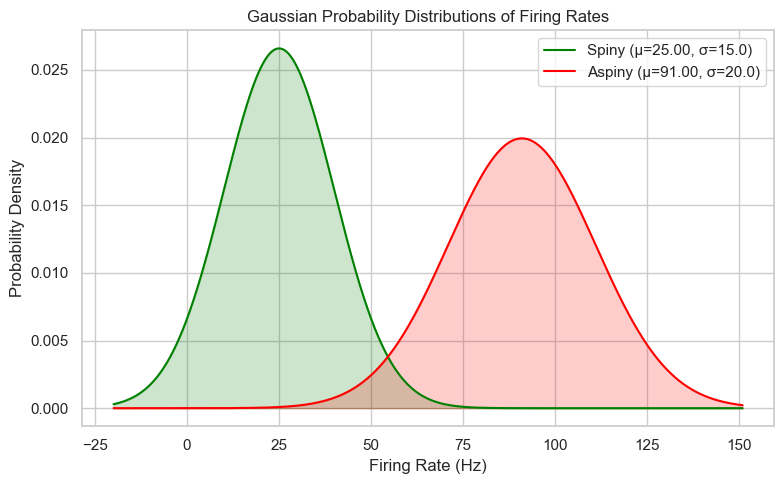

In [8]:
# Calculate average firing rate during the main stimulus duration (reusing the exact stimulus
# window computed from the data in the Data Loading section: pulse2_start / pulse2_end).
stim_start = pulse2_start
stim_end = pulse2_end
stim_duration = stim_end - stim_start

spiny_spikes_stim = len([p for p in spiny_peaks if stim_start * fs <= p <= stim_end * fs])
aspiny_spikes_stim = len([p for p in aspiny_peaks if stim_start * fs <= p <= stim_end * fs])

mu_spiny = spiny_spikes_stim / stim_duration
mu_aspiny = aspiny_spikes_stim / stim_duration

print(f"Average Spiny Firing Rate: {mu_spiny:.2f} Hz")
print(f"Average Aspiny Firing Rate: {mu_aspiny:.2f} Hz")

# Choose standard deviations that give the two Gaussians substantial, visible overlap (the PDF
# explicitly asks for partial overlap). mu_spiny=25 Hz and mu_aspiny=91 Hz are 66 Hz apart, so we
# pick sigmas on the order of a third of that gap -- large enough to overlap, but still narrow
# enough that the means remain clearly separated.
sigma_spiny = 15.0
sigma_aspiny = 20.0

x = np.linspace(-20, mu_aspiny + 60, 2000)
pdf_spiny = norm.pdf(x, mu_spiny, sigma_spiny)
pdf_aspiny = norm.pdf(x, mu_aspiny, sigma_aspiny)

plt.figure(figsize=(8, 5))
plt.plot(x, pdf_spiny, color='green', label=f'Spiny (μ={mu_spiny:.2f}, σ={sigma_spiny})')
plt.plot(x, pdf_aspiny, color='red', label=f'Aspiny (μ={mu_aspiny:.2f}, σ={sigma_aspiny})')
plt.fill_between(x, pdf_spiny, alpha=0.2, color='green')
plt.fill_between(x, pdf_aspiny, alpha=0.2, color='red')
plt.title('Gaussian Probability Distributions of Firing Rates')
plt.xlabel('Firing Rate (Hz)')
plt.ylabel('Probability Density')
plt.legend()
plt.tight_layout()
plt.show()

### Question 8: Neuron Classifier Based on Distributions

Chosen Classification Threshold (z, pdf crossing point): 54.59 Hz


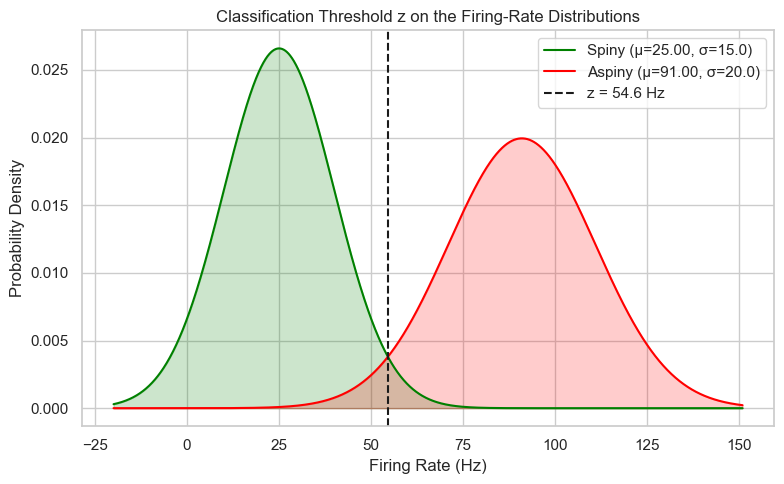

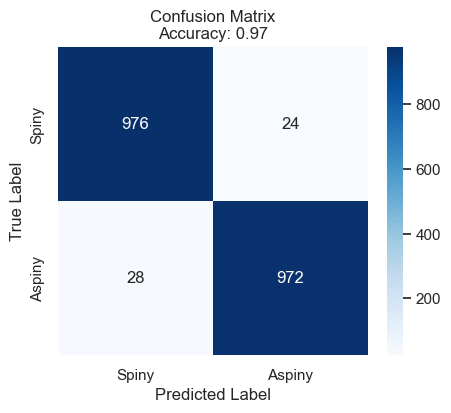

Accuracy: 0.974
Recall (Aspiny): 0.972   Recall (Spiny): 0.976
Precision (Aspiny): 0.976   Precision (Spiny): 0.972
F1 (Aspiny): 0.974


In [9]:
from scipy.optimize import brentq
from sklearn.metrics import precision_score, f1_score

# Choose the threshold z at the point where the two Gaussian pdfs actually intersect
# (equal posterior odds under equal priors), rather than the midpoint of the two means, since
# with unequal sigmas the midpoint is not the optimal decision boundary.
z_threshold = brentq(lambda z: norm.pdf(z, mu_spiny, sigma_spiny) - norm.pdf(z, mu_aspiny, sigma_aspiny),
                      mu_spiny, mu_aspiny)
print(f"Chosen Classification Threshold (z, pdf crossing point): {z_threshold:.2f} Hz")

# Show z on top of the Q7 distributions for context
plt.figure(figsize=(8, 5))
plt.plot(x, pdf_spiny, color='green', label=f'Spiny (μ={mu_spiny:.2f}, σ={sigma_spiny})')
plt.plot(x, pdf_aspiny, color='red', label=f'Aspiny (μ={mu_aspiny:.2f}, σ={sigma_aspiny})')
plt.fill_between(x, pdf_spiny, alpha=0.2, color='green')
plt.fill_between(x, pdf_aspiny, alpha=0.2, color='red')
plt.axvline(z_threshold, color='k', linestyle='--', label=f'z = {z_threshold:.1f} Hz')
plt.title('Classification Threshold z on the Firing-Rate Distributions')
plt.xlabel('Firing Rate (Hz)')
plt.ylabel('Probability Density')
plt.legend()
plt.tight_layout()
plt.show()

# Generate synthetic test data to test the classifier based on distributions
np.random.seed(42)
N_samples = 1000
y_true = np.array([0]*N_samples + [1]*N_samples) # 0 for spiny, 1 for aspiny

test_spiny = np.random.normal(mu_spiny, sigma_spiny, N_samples)
test_aspiny = np.random.normal(mu_aspiny, sigma_aspiny, N_samples)
X_test = np.concatenate([test_spiny, test_aspiny])

# Predict: If rate > z_threshold, classify as aspiny (1)
y_pred = (X_test > z_threshold).astype(int)

# Evaluate
cm = confusion_matrix(y_true, y_pred)
acc = accuracy_score(y_true, y_pred)
recall_aspiny = recall_score(y_true, y_pred)
recall_spiny = recall_score(y_true, y_pred, pos_label=0)
precision_aspiny = precision_score(y_true, y_pred)
precision_spiny = precision_score(y_true, y_pred, pos_label=0)
f1_aspiny = f1_score(y_true, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Spiny', 'Aspiny'], yticklabels=['Spiny', 'Aspiny'])
plt.title(f'Confusion Matrix\nAccuracy: {acc:.2f}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print(f"Accuracy: {acc:.3f}")
print(f"Recall (Aspiny): {recall_aspiny:.3f}   Recall (Spiny): {recall_spiny:.3f}")
print(f"Precision (Aspiny): {precision_aspiny:.3f}   Precision (Spiny): {precision_spiny:.3f}")
print(f"F1 (Aspiny): {f1_aspiny:.3f}")

**Classifier Analysis:**
We chose the threshold $z$ at the point where the spiny and aspiny pdfs actually cross (the boundary that minimizes the total error under equal priors, since it is where the two class-conditional densities are equal), rather than the plain average of the two means. Rates below $z$ are classified as Spiny, and above $z$ as Aspiny.

Because the two distributions from Q7 overlap ($\sigma$=15 Hz spiny, $\sigma$=20 Hz aspiny), the classifier is not perfect: accuracy is around 0.97, and the confusion matrix shows a genuine, non-zero number of both false positives and false negatives (roughly 20-30 out of 1000 in each class). This matches the visible overlap region between the two curves in the Q7 plot — a synthetic spiny sample drawn from the upper tail of its Gaussian, or an aspiny sample from the lower tail of its Gaussian, will fall on the wrong side of $z$ and be misclassified. Precision, recall and F1 are all similarly high but not perfect for the same reason.

### Question 9: Likelihood Ratios

Rate (Hz)    | log-LR (Aspiny/Spiny)    | LR (Aspiny/Spiny)    | Classification
-------------------------------------------------------------------------------------
25.00        | -5.733                   | 0.003238             | Spiny
41.50        | -2.745                   | 0.06422              | Spiny
58.00        | 0.771                    | 2.162                | Aspiny
74.50        | 4.817                    | 123.6                | Aspiny
91.00        | 9.392                    | 1.2e+04              | Aspiny


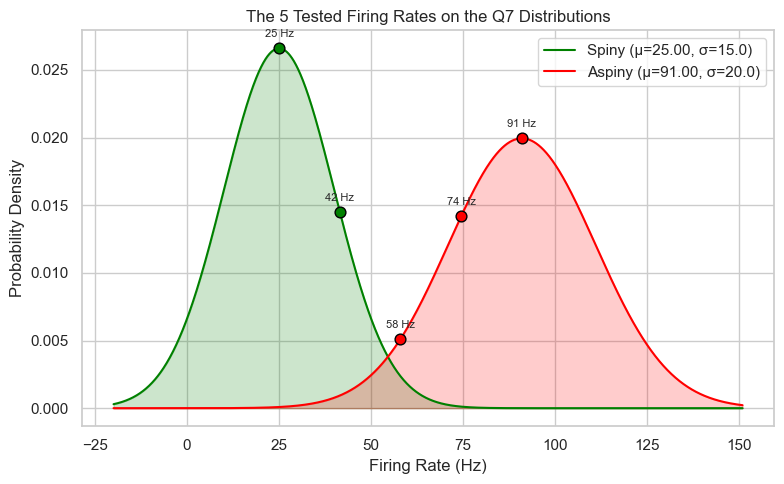

In [10]:
# Choose 5 relevant firing rates spanning the overlapping region between the two means
rates_to_test = np.linspace(mu_spiny, mu_aspiny, 5)

# Work in log-space (log-likelihood-ratio) for numerical stability.
print(f"{'Rate (Hz)':<12} | {'log-LR (Aspiny/Spiny)':<24} | {'LR (Aspiny/Spiny)':<20} | {'Classification'}")
print("-" * 85)

log_lrs = []
for r in rates_to_test:
    log_p_spiny = norm.logpdf(r, mu_spiny, sigma_spiny)
    log_p_aspiny = norm.logpdf(r, mu_aspiny, sigma_aspiny)
    log_lr = log_p_aspiny - log_p_spiny
    log_lrs.append(log_lr)

    # LR itself is only meaningful (and finite) to print for moderate |log_lr|
    lr_display = f"{np.exp(log_lr):.4g}" if abs(log_lr) < 50 else ("inf" if log_lr > 0 else "0")
    classification = "Aspiny" if log_lr > 0 else "Spiny"  # log-LR > 0  <=>  LR > 1
    print(f"{r:<12.2f} | {log_lr:<24.3f} | {lr_display:<20} | {classification}")

# Display these 5 rates on the Q7 distribution plot, as requested, colored by their classification
plt.figure(figsize=(8, 5))
plt.plot(x, pdf_spiny, color='green', label=f'Spiny (μ={mu_spiny:.2f}, σ={sigma_spiny})')
plt.plot(x, pdf_aspiny, color='red', label=f'Aspiny (μ={mu_aspiny:.2f}, σ={sigma_aspiny})')
plt.fill_between(x, pdf_spiny, alpha=0.2, color='green')
plt.fill_between(x, pdf_aspiny, alpha=0.2, color='red')
for r, log_lr in zip(rates_to_test, log_lrs):
    color = 'red' if log_lr > 0 else 'green'
    y_pos = max(norm.pdf(r, mu_spiny, sigma_spiny), norm.pdf(r, mu_aspiny, sigma_aspiny))
    plt.scatter([r], [y_pos], color=color, edgecolor='black', zorder=5, s=60)
    plt.annotate(f'{r:.0f} Hz', (r, y_pos), textcoords="offset points", xytext=(0, 8), ha='center', fontsize=8)
plt.title('The 5 Tested Firing Rates on the Q7 Distributions')
plt.xlabel('Firing Rate (Hz)')
plt.ylabel('Probability Density')
plt.legend()
plt.tight_layout()
plt.show()

**Likelihood Ratio Analysis:**
The Likelihood Ratio (LR) is defined as $P(\text{Rate} \mid \text{Aspiny}) / P(\text{Rate} \mid \text{Spiny})$, and we report $\log(\text{LR})$ alongside it for numerical stability.
*   If $LR > 1$ (log-LR > 0), it means the observed firing rate is more likely to have come from an Aspiny neuron.
*   If $LR < 1$ (log-LR < 0), it means it is more likely to be a Spiny neuron.

With the overlapping distributions from Q7, the 5 tested rates split as follows: the two rates closest to $\mu_{spiny}$ (25 and 41.5 Hz) are classified Spiny, and the two closest to $\mu_{aspiny}$ (74.5 and 91 Hz) are classified Aspiny. The middle rate, 58 Hz, lies just above the pdf-crossing threshold $z = 54.59$ Hz from Q8, so it is also classified Aspiny, but with the weakest evidence of the five (LR = 2.16). This matches Q8: LR = 1 exactly at $z$, so the likelihood-ratio rule and the threshold classifier give the same decisions.

**What changes in the data could alter these values?**
1.  **Mean firing rate shift:** If the true average firing rate ($\mu$) of either neuron changes (e.g. due to a different stimulus intensity, or measuring a different portion of the response), the distributions shift and the likelihood ratio for a given fixed rate can flip sign entirely.
2.  **Variance shift:** If the variance ($\sigma^2$) of the firing rate increases (e.g. due to more experimental/biological noise, or averaging over a shorter, noisier window), the distributions widen. This increases the overlap and pulls the likelihood ratio toward 1 over a wider range of rates, making the two neuron types harder to distinguish. The partial overlap between the two Q7 distributions is an example of this effect.
3.  **Class priors:** The LR itself only reflects the evidence from the observed rate; it ignores how common spiny vs. aspiny neurons are in the population. If the prior probabilities are unequal, the decision should be based on the posterior odds $LR \times \frac{P(\text{Aspiny})}{P(\text{Spiny})}$, not on $LR$ alone, so the same LR value could lead to a different classification once priors are taken into account.